<a href="https://colab.research.google.com/github/emirpeker/Veri-Analizi-Okulu/blob/main/Veri_Analiz_Okulu%2C_Yapay_Zeka__Makina_%C3%96%C4%9Frenmesi%2C_Ders_6_Uygulama__SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Support Vector Machines - Destek Vektör Makineleri (SVM)

Destek Vektör Makineleri (Support Vector Machines - SVM), hem sınıflandırma hem de regresyon problemlerinde kullanılan güçlü bir makine öğrenmesi yöntemidir. Temel amaç, farklı sınıflara ait verileri en iyi ayıran hiper-düzlemi (hyperplane) bulmaktır.

SVM algoritması bu hiper-düzlemi seçerken marjin (margin) adı verilen iki sınıf arasındaki mesafeyi maksimum yapmaya çalışır. Bu yaklaşım sayesinde model genellikle iyi genelleme performansı gösterir.

Modüllerin Yüklenmesi

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Veri Setinin Yüklenmesi

In [7]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Özellik sayısı:", X.shape[1])
print("Örnek sayısı:", X.shape[0])

Özellik sayısı: 30
Örnek sayısı: 569


DataFrame Oluşturma

In [8]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Sınıf Dağılımını Görselleştirme

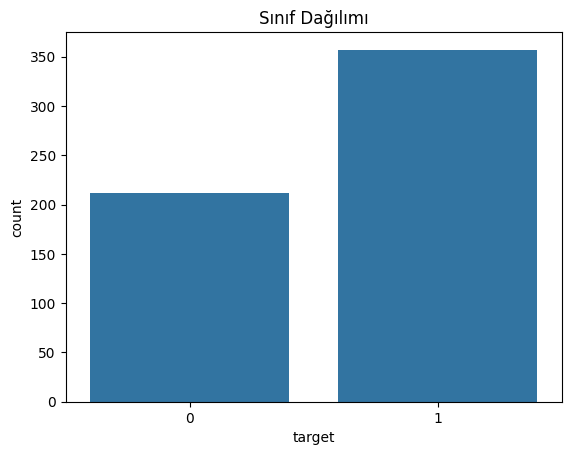

In [9]:
sns.countplot(x="target", data=df)
plt.title("Sınıf Dağılımı")
plt.show()

0 → malignant (kötü huylu)

1 → benign (iyi huylu)

Bu grafik veri setinin dengesini görmemizi sağlar.

Veri Setinin Train-Test Olarak Bölünmesi

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train veri boyutu:", X_train.shape)
print("Test veri boyutu:", X_test.shape)

Train veri boyutu: (455, 30)
Test veri boyutu: (114, 30)


%80 eğitim

%20 test

Feature Scaling (Ölçeklendirme)

SVM algoritması ölçek farklarına duyarlıdır, bu nedenle veri ölçeklendirilmelidir.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SVM Modelinin Oluşturulması

İlk olarak linear kernel kullanalım.

In [12]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train_scaled, y_train)

SVC(kernel='linear')

Tahmin Yapma

In [20]:
y_pred = svm_model.predict(X_test_scaled)

print(y_pred[:10])

[1 0 0 1 1 0 0 0 0 1]


Model Performansının Değerlendirilmesi

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


Karmaşıklık Matrisi

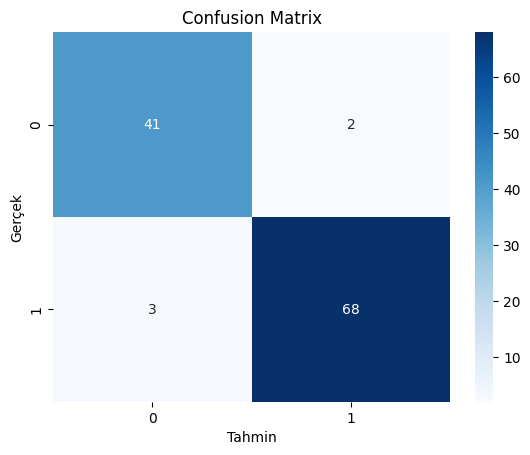

In [15]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()

Sınıflandırma Raporu

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



Farklı Kernel Fonksiyonlarının Karşılaştırılması

RBF Kernel

In [17]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("RBF Doğruluğu:", accuracy_score(y_test, y_pred_rbf))

RBF Doğruluğu: 0.9824561403508771


Polynomial Kernel

In [18]:
svm_poly = SVC(kernel='poly', degree=3)

svm_poly.fit(X_train_scaled, y_train)

y_pred_poly = svm_poly.predict(X_test_scaled)

print("Polynomial Doğruluğu:", accuracy_score(y_test, y_pred_poly))

Polynomial Doğruluğu: 0.868421052631579


Sonuçların Karşılaştırılması

In [19]:
results = pd.DataFrame({
    "Model": ["Linear SVM", "RBF SVM", "Polynomial SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_poly)
    ]
})

results

,Model,Accuracy
0,Linear SVM,0.956140
1,RBF SVM,0.982456
2,Polynomial SVM,0.868421
